In [13]:
import numpy as np
import matplotlib
#matplotlib.use("Agg")           # headless rendering
import matplotlib.pyplot as plt
 
from afd_vmodel  import afd_vmodel
from afd_explode import afd_explode
from wavemin    import wavemin
from surround   import surround

In [32]:
# ── Model parameters ──────────────────────────────────────────────────────────
dx        = 2       # grid spacing (m)
xmax      = 2500    # max x (m)
zmax      = 1000    # max z (m)

# v(z) layer bottoms and velocities
zlayers = [50, 100, 200, 250, 300, 330, 380, 400]   # depths to layer bottoms (m)
vlayers = [2000, 2100, 2200, 2400, 2500, 2800, 3000, 3100]  # layer velocities (m/s)

x=np.arange(0,xmax+dx,dx)
z=np.arange(0,zmax+dx,dx)


In [33]:
nx = len(x)
nz = len(z)
print([nx,nz])

[1251, 501]


In [34]:
# Half-space at 4000 m/s; layers will overwrite
vel = 4000.0 * np.ones((len(z), len(x)))

In [26]:
vel.shape

(501, 1251)

In [35]:
# Install each v(z) layer
for k, (z1, vk) in enumerate(zip(zlayers, vlayers)):
    z0 = 0.0 if k == 0 else zlayers[k - 1]
    xpoly = np.array([-dx,      xmax + dx, xmax + dx, -dx      ])
    zpoly = np.array([ z0 - dx,  z0 - dx,  z1 + dx,   z1 + dx  ])
    vel = afd_vmodel(dx, vel, vk, xpoly, zpoly)

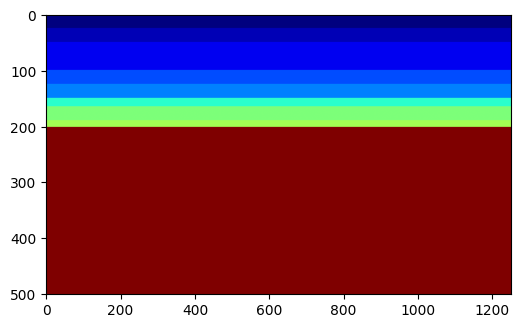

In [36]:
plt.figure(figsize=[6,6])
plt.imshow(vel, cmap='jet',aspect=1.5)
plt.show()

In [37]:
# =============================================================================
# 3.  Parabolic anticline
# =============================================================================
x0   = xmax / 2.0   # crest x-position (m)
z0c  = 600.0        # crest depth (m)
a    = 5e-4         # flank steepness  (m^-1 … units of a*(x-x0)^2 = m)
 
za   = a * (x - x0) ** 2 + z0c   # parabolic depth curve
 
# Polygon that encloses the anticline down to zmax
ind    = surround(za, zmax + dx)
i1, i2 = ind[0], ind[1]
 
xpoly  = np.concatenate([x[i1:i2 + 1],
                          [x[i2], x[i1]]])
zpoly  = np.concatenate([za[i1:i2 + 1],
                          [zmax + dx, zmax + dx]])
 
vanti  = 5000.0     # anticline velocity (m/s)
vel    = afd_vmodel(dx, vel, vanti, xpoly, zpoly)

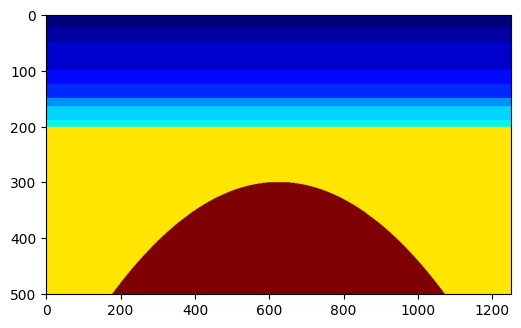

In [38]:
plt.figure(figsize=[6,6])
plt.imshow(vel, cmap='jet',aspect=1.5)
plt.show()

In [39]:
dt      = 0.004         # output sample interval (s)
dtstep  = 0.0005        # FD time step (s)
tmax_fd = 2 * zmax / 2000.0   # max record time (s)  ≈ 1.0 s
 
# Minimum-phase wavelet at 30 Hz, 0.2 s long
w, tw = wavemin(dt, 30.0, 0.2)
 
# Surface receivers at every x position, z = 0
xrec = x.copy()
zrec = np.zeros_like(xrec)
 
# Run the model
#   wlet = w  (wavelet time-series)
#   tw   = tw (time vector for wavelet)
#   Ormsby-filter path is NOT used here; wavelet convolution path is used.
seisfilt, seis, t = afd_explode(
    dx       = dx,
    dtstep   = dtstep,
    dt       = dt,
    tmax     = tmax_fd,
    velocity = vel,
    xrec     = xrec,
    zrec     = zrec,
    wlet     = w,
    tw       = tw,
    laplacian = 1,
    boundary  = 2,
    zmin      = 0.0,
)

There are 2000 steps to complete.
  wavefield propagated to 0.0405 s; time left ≈ 11.7 s
  wavefield propagated to 0.0810 s; time left ≈ 10.6 s
  wavefield propagated to 0.1215 s; time left ≈ 10.7 s
  wavefield propagated to 0.1620 s; time left ≈ 10.0 s
  wavefield propagated to 0.2025 s; time left ≈ 9.3 s
  wavefield propagated to 0.2430 s; time left ≈ 8.6 s
  wavefield propagated to 0.2835 s; time left ≈ 7.9 s
  wavefield propagated to 0.3240 s; time left ≈ 7.4 s
  wavefield propagated to 0.3645 s; time left ≈ 6.9 s
  wavefield propagated to 0.4050 s; time left ≈ 6.4 s
  wavefield propagated to 0.4455 s; time left ≈ 5.9 s
  wavefield propagated to 0.4860 s; time left ≈ 5.5 s
  wavefield propagated to 0.5265 s; time left ≈ 5.0 s
  wavefield propagated to 0.5670 s; time left ≈ 4.6 s
  wavefield propagated to 0.6075 s; time left ≈ 4.1 s
  wavefield propagated to 0.6480 s; time left ≈ 3.7 s
  wavefield propagated to 0.6885 s; time left ≈ 3.2 s
  wavefield propagated to 0.7290 s; time lef

In [40]:
smin,smax=np.percentile(seis,[1,99])

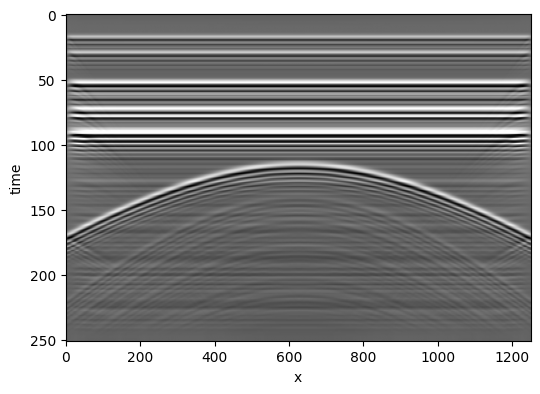

In [43]:
fig2=plt.figure(figsize=[6,6])
plt.imshow(seis, cmap='gray', vmin=smin, vmax=smax,aspect=3.5)
plt.xlabel('x')
plt.ylabel('time')
plt.show()